# Notebook 1 — Data Understanding
## Telecom Customer Retention Intelligence Platform

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.3f' % x)

print("Libraries loaded successfully")

Libraries loaded successfully


## Load dataset

In [2]:
df = pd.read_csv('../data/raw/Telco-Customer-Churn.csv')

print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

Dataset shape: (7043, 21)
Rows: 7,043
Columns: 21


In [3]:
## 2. First Look at the Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.850,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.950,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.850,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.300,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.700,151.65,Yes


In [5]:
print("Column Data Types")
print("=" * 40)
print(df.dtypes)

Column Data Types
customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


## 3. Data Quality Checks
### 3.1 Missing Values

In [ ]:
print("Missing Value Check")
print("=" * 42)

missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_pct
})

print(missing_df[missing_df['Missing Count'] > 0])
print("\nNote: Check TotalCharges for blank strings separately")

# Check for blank strings specifically in TotalCharges
blank_total_charges = df[df['TotalCharges'] == ' '].shape[0]
print(f"\nBlank strings in TotalCharges: {blank_total_charges}")

Missing Value Check
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Note: Check TotalCharges for blank strings separately

Blank strings in TotalCharges: 11


### 3.2 Duplicate Records

In [7]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows: {duplicates}")

duplicate_ids = df['customerID'].duplicated().sum()
print(f"Duplicate customer IDs: {duplicate_ids}")

Duplicate rows: 0
Duplicate customer IDs: 0


Churn Distribution
No: 5,174 (73.5%)
Yes: 1,869 (26.5%)


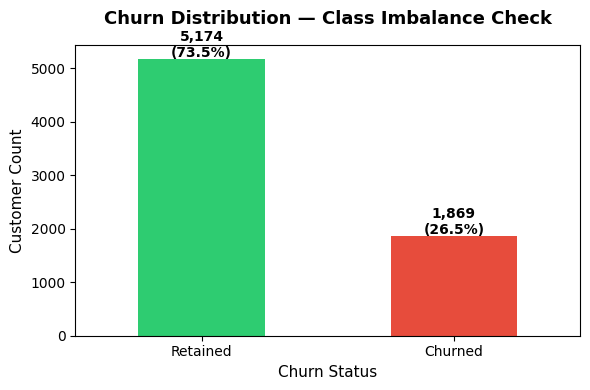

Chart saved to reports/


In [8]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn Distribution")
print("=" * 40)
for label in churn_counts.index:
    print(f"{label}: {churn_counts[label]:,} ({churn_pct[label]:.1f}%)")

# Visualize
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#2ecc71', '#e74c3c']
churn_counts.plot(kind='bar', color=colors, ax=ax, edgecolor='none')
ax.set_title('Churn Distribution — Class Imbalance Check', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Churn Status', fontsize=11)
ax.set_ylabel('Customer Count', fontsize=11)
ax.set_xticklabels(['Retained', 'Churned'], rotation=0)

for i, v in enumerate(churn_counts):
    ax.text(i, v + 30, f'{v:,}\n({churn_pct.iloc[i]:.1f}%)', 
            ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved to reports/")

### 3.4 Numerical Columns — Distribution and Outliers

In [9]:
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Convert TotalCharges first for this check
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("Numerical Columns Summary")
print("=" * 40)
print(df[numerical_cols].describe())

Numerical Columns Summary
        tenure  MonthlyCharges  TotalCharges
count 7043.000        7043.000      7032.000
mean    32.371          64.762      2283.300
std     24.559          30.090      2266.771
min      0.000          18.250        18.800
25%      9.000          35.500       401.450
50%     29.000          70.350      1397.475
75%     55.000          89.850      3794.738
max     72.000         118.750      8684.800


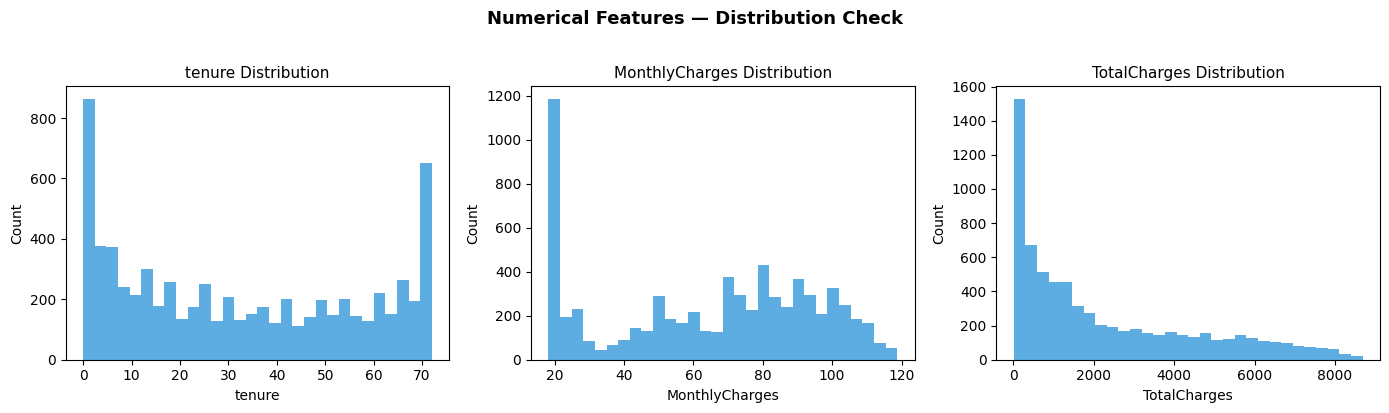

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col].dropna(), bins=30, 
                 color='#3498db', edgecolor='none', alpha=0.8)
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Numerical Features — Distribution Check', 
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/numerical_distributions.png', 
            dpi=150, bbox_inches='tight')
plt.show()

### 3.5 SeniorCitizen Encoding Check

In [13]:
print("SeniorCitizen unique values:", df['SeniorCitizen'].unique())
print("SeniorCitizen value counts:")
print(df['SeniorCitizen'].value_counts())


SeniorCitizen unique values: [0 1]
SeniorCitizen value counts:
SeniorCitizen
0    5901
1    1142
Name: count, dtype: int64
